In [1]:
from google.colab import files
uploaded = files.upload()

Saving heart-disease.csv to heart-disease.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

import joblib


In [3]:
df = pd.read_csv("heart-disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [5]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
df.shape

(303, 14)

In [7]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [8]:
df.duplicated().sum()

np.int64(1)

In [9]:
df= df.drop_duplicates()

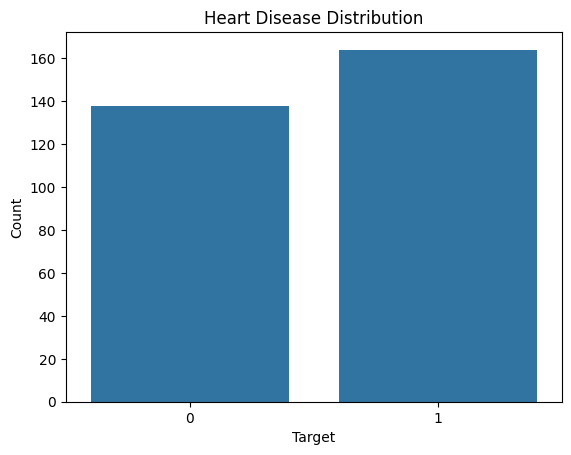

In [10]:
#EDA
sns.countplot(x="target", data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

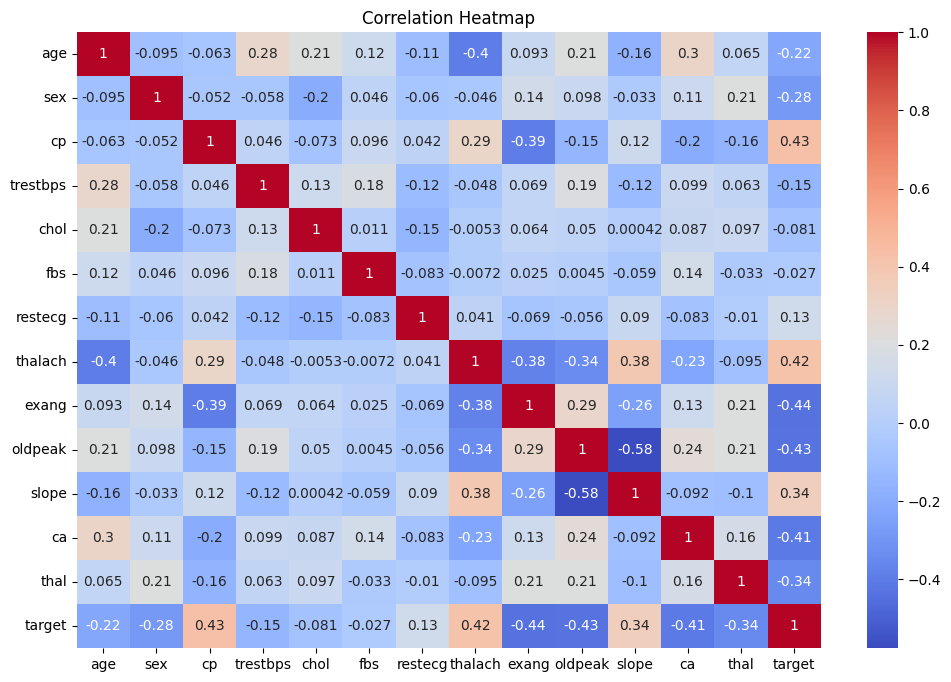

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


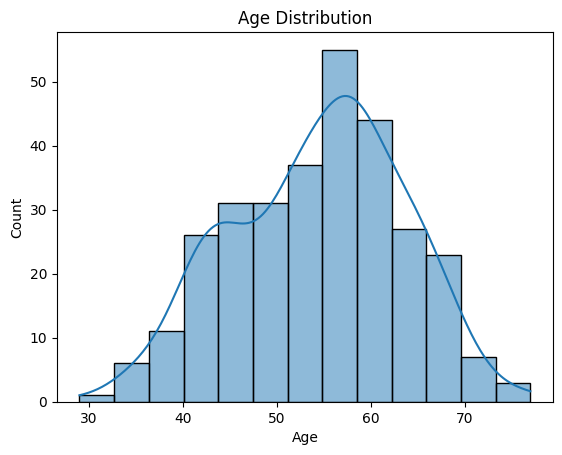

In [12]:
sns.histplot(df["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

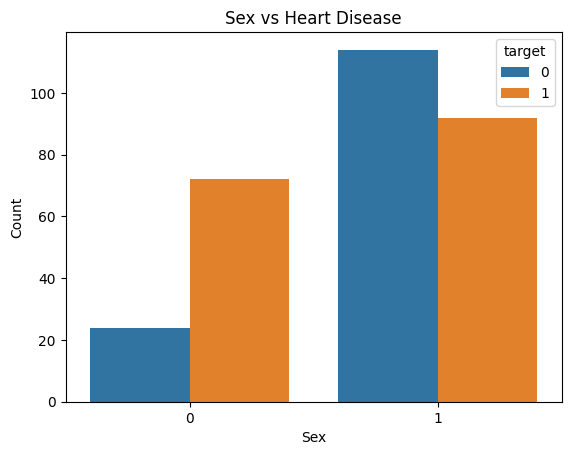

In [13]:
sns.countplot(x="sex", hue="target", data=df)
plt.title("Sex vs Heart Disease")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

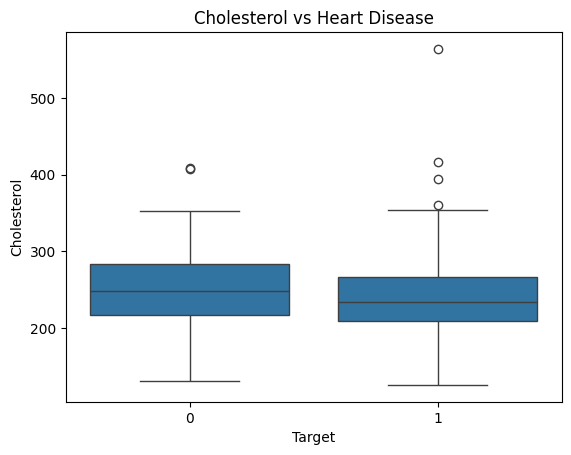

In [14]:
sns.boxplot(x="target", y="chol", data=df)
plt.title("Cholesterol vs Heart Disease")
plt.xlabel("Target")
plt.ylabel("Cholesterol")
plt.show()


In [15]:
X = df.drop("target", axis=1)
y = df["target"]


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [17]:
scalar = StandardScaler()
X_train_scaled = scalar.fit_transform(X_train)
X_test_scaled = scalar.transform(X_test)


In [18]:
#decision tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", dt_accuracy)


Decision Tree Accuracy: 0.7704918032786885


In [19]:
#random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8688524590163934


In [20]:
#XGBoost
!pip install xgboost
from xgboost import XGBClassifier
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss")
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))

XGBoost Accuracy: 0.8360655737704918


In [21]:
#Hyperparameters tuning
dt_model_params = {"max_depth": [3,5,10,None], "min_samples_split": [2,5,10], "criterion": ["gini", "entropy"]}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_model_params, cv=5, scoring= "accuracy", n_jobs=-1)
dt_grid.fit(X_train, y_train)
best_dt_model = dt_grid.best_estimator_

In [22]:
rf_model_params = {"n_estimators": [100,200,300], "max_depth": [5,10,None], "min_samples_split": [2,5,10], "criterion": ["gini", "entropy"]}
rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), rf_model_params, cv=5, scoring= "accuracy", n_jobs=-1)
rf_grid.fit(X_train, y_train)
best_rf_model = rf_grid.best_estimator_

In [30]:
xgb_model_params = {"n_estimators": [100,200],"learning_rate": [0.01, 0.1,0.2], "max_depth": [3,5,7]}
xgb_grid = GridSearchCV(XGBClassifier(random_state=42, eval_metric="logloss"), xgb_model_params, cv=5, scoring= "accuracy", n_jobs=-1)
xgb_grid.fit(X_train, y_train)
best_xgb_model = xgb_grid.best_estimator_

In [36]:
#compare models
results = []

models = [
   ("Decision Tree", best_dt_model),
   ("Random Forest", best_rf_model),
   ("XGBoost", best_xgb_model)
]

for name, model in models:

    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results.append((name, accuracy))
comparison = pd.DataFrame(results, columns=["Model", "Accuracy"])
print(comparison.sort_values(by = "Accuracy", ascending=False))

           Model  Accuracy
1  Random Forest  0.852459
2        XGBoost  0.852459
0  Decision Tree  0.803279


In [37]:
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.81      0.86      0.83        29
           1       0.87      0.81      0.84        32

    accuracy                           0.84        61
   macro avg       0.84      0.84      0.84        61
weighted avg       0.84      0.84      0.84        61



Text(70.72222222222221, 0.5, 'Actual')

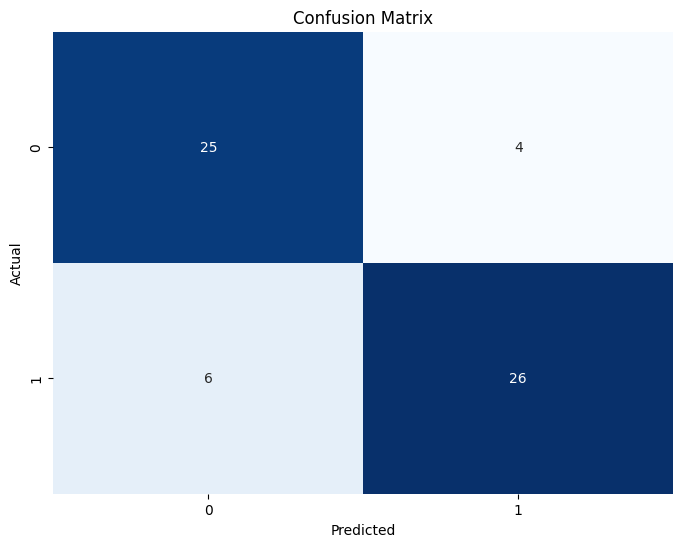

In [38]:
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

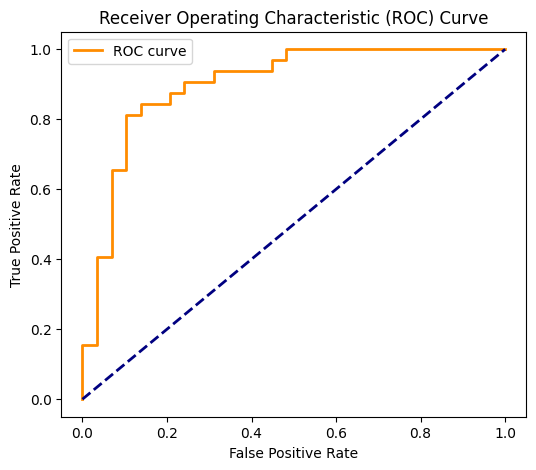

In [39]:
#ROC CURVE
y_pred_prob = best_xgb_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label="ROC curve")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC) Curve")
plt.legend()
plt.show()

In [40]:
#Feature importance
importance = pd.DataFrame({"Feature": X.columns, "Importance": best_xgb_model.feature_importances_})
importance = importance.sort_values(by="Importance", ascending=False)
print(importance)

     Feature  Importance
12      thal    0.291579
11        ca    0.141975
2         cp    0.109377
8      exang    0.094745
9    oldpeak    0.072285
10     slope    0.062732
1        sex    0.052171
0        age    0.042304
4       chol    0.031076
3   trestbps    0.029825
7    thalach    0.028526
6    restecg    0.023779
5        fbs    0.019625


In [41]:
#save model
joblib.dump(best_xgb_model, "heart_disease_model.pkl")
joblib.dump(scalar, "scaler.pkl")

['scaler.pkl']